In [1]:
# Set Font-Style
from IPython.display import display, HTML
display(HTML("""
<link href="https://fonts.googleapis.com/css2?family=Crimson+Pro&display=swap" rel="stylesheet">
<link href="https://cdn.jsdelivr.net/gh/dreampulse/computer-modern-web-font@master/fonts.css" rel="stylesheet">
<link href="https://fonts.googleapis.com/css2?family=Martian+Mono&display=swap" rel="stylesheet">
<style>
.jp-MarkdownOutput code {
    font-family: Consolas, monospace !important;
    font-size: 15px !important;
    background: #f5f5f5;
    padding: 1px 3px;
    border-radius: 4px;
}

.jp-MarkdownOutput pre {
    font-family: Consolas, monospace !important;
    font-size: 14px !important;
    background: #f5f5f5;
    padding: 10px;
    border-radius: 4px;
}
    .jp-MarkdownOutput p  { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.25; }
    .jp-MarkdownOutput td { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.25; }
    .jp-MarkdownOutput li { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.50; }
    .jp-MarkdownOutput h1 { font-family: 'Crimson Pro', serif; font-size: 32px; }
    .jp-MarkdownOutput h2 { font-family: 'Crimson Pro', serif; font-size: 26px; }
    .jp-MarkdownOutput h3 { font-family: 'Crimson Pro', serif; font-size: 22px; }
    .jp-MarkdownOutput h4 { font-family: 'Crimson Pro', serif; font-size: 18px; }
</style>
"""))


In [2]:
# Imports
import time
import math, cmath
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [3]:
# Timer 
class Timer:
    def __init__(self):
        self._time = time.time()
    def set(self):
        self._time = time.time()
    def lap(self, p=3):
        t = time.time() - self._time
        self._time = time.time()
        return f"{t:.{p}f}"
    def stop(self, p=3):
        t = time.time() - self._time
        self._time = 0.0
        return t
timer = Timer()

# **Fourier Transforms & the Fast Fourier Transform (Part 1)**
--- 

# FFTs — Quick Reference

---

## The Problem FFT Solves

Any signal can be decomposed into a sum of sine waves at different frequencies.
The **DFT** computes this decomposition for discrete signals — but naively costs **O(N²)**.
The **FFT** computes the exact same result in **O(N log N)** by recursively exploiting symmetry.

---

## Fourier Series — Periodic Signals

$$f(t) = \frac{a_0}{2} + \sum_{k=1}^{\infty} \left( a_k \cos(2\pi k f t) + b_k \sin(2\pi k f t) \right)$$

- **a₀/2** — average value of the signal (DC offset, zero frequency)
- **aₖ** — how much cosine at frequency k
- **bₖ** — how much sine at frequency k
- Only integer multiples of base frequency f exist → **discrete spectrum**

---

## Fourier Transform — Aperiodic Continuous Signals

$$F(\omega) = \int_{-\infty}^{\infty} f(t) \cdot e^{-i\omega t} \, dt$$

- **F(ω)** — complex number at every frequency ω
- **|F(ω)|** — magnitude, how much of frequency ω is present
- **∠F(ω)** — phase, where in the cycle that frequency starts
- Every frequency exists → **continuous spectrum**

**Inverse:**

$$f(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} F(\omega) \cdot e^{+i\omega t} \, d\omega$$

- Sign on exponent flips — undoes the forward rotation
- 1/2π normalization balances the forward transform
- Reconstructs f(t) exactly — no information lost

---

## DFT — Discrete Finite Signals

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-i2\pi kn/N}$$

- **x[n]** — your N input samples
- **X[k]** — complex number at frequency bin k
- **k** — frequency index, 0 to N-1
- **n** — time sample index, 0 to N-1
- Costs **O(N²)** — N outputs, each requires N multiplications

**Inverse DFT:**

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \cdot e^{+i2\pi kn/N}$$

- 1/N normalization — convention, balances forward transform
- Sign flips on exponent — same as continuous case

---

## The Complex Exponential

$$e^{-i\omega t} = \cos(\omega t) - i\sin(\omega t)$$

- Traces the **unit circle** in the complex plane as t increases
- Real part → cosine component at frequency ω
- Imaginary part → sine component at frequency ω
- Packages both sine and cosine into one term — cleaner than writing both separately
- **ω = 2πf** — angular frequency (radians/sec), f is cycles/sec (Hz)

Multiplying f(t) by e^{-iωt} and integrating asks:
> *"How much does my signal look like a wave at frequency ω?"*
If the signal contains ω, contributions add up. If not, they cancel.

---

## FFT — Fast Algorithm for DFT

Split the N-point DFT into two N/2-point DFTs (even and odd samples):

$$X[k] = \underbrace{\sum_{n=0}^{N/2-1} x[2n] \cdot e^{-i2\pi kn/(N/2)}}_{E[k]} + e^{-i2\pi k/N} \underbrace{\sum_{n=0}^{N/2-1} x[2n+1] \cdot e^{-i2\pi kn/(N/2)}}_{O[k]}$$

$$X[k] = E[k] + e^{-i2\pi k/N} \cdot O[k]$$
$$X[k + N/2] = E[k] - e^{-i2\pi k/N} \cdot O[k]$$

- **E[k]** — DFT of even-indexed samples
- **O[k]** — DFT of odd-indexed samples  
- **e^{-i2πk/N}** — twiddle factor, precomputed rotation
- ± relationship means one E[k], O[k] pair produces **two outputs for free**
- Recurse until size 1 (trivial) → **O(N log N)**

---

## Convolution Theorem

$$f * g \iff F(\omega) \cdot G(\omega)$$

Convolution in time/space = pointwise multiplication in frequency.

**FFT Convolution pipeline:**
1. Zero pad both signals to length N + K - 1 → prevents circular convolution
2. FFT both → O(N log N)
3. Multiply pointwise → O(N)
4. Inverse FFT → O(N log N)

Total: **O(N log N)** — independent of kernel size K.

---

## Key Facts

| | Fourier Series | Fourier Transform | DFT / FFT |
|---|---|---|---|
| Signal type | periodic, continuous | aperiodic, continuous | discrete, finite |
| Spectrum | discrete | continuous | discrete |
| Computable | no | no | yes |

- **FFT ≠ approximation** — exact same result as DFT, just faster
- **Periodicity assumption** — DFT treats your N samples as one period of an infinite repeating sequence → always zero pad for convolution
- **rfft** — for real signals, spectrum is symmetric, only N/2+1 unique values needed
- **ω = 2πf** — angular vs regular frequency, same thing different units

## Discrete Fourier Transform

Before jumping into the FFT, we need to understand what it's actually computing — and that 
starts with the DFT. <br>

The core idea is simple: any discrete signal can be decomposed into a sum of sine waves at 
different frequencies. The DFT answers the question — *which frequencies are present, and 
how much of each?* It does this by taking N input samples and producing N complex numbers, 
one per frequency bin, each encoding the magnitude and phase of that frequency in the signal. <br>

The catch is cost. For every frequency bin, the DFT sums over every input sample — 
that's N bins times N samples, giving us **O(N²)**. For small signals this is fine. 
For anything large it becomes the bottleneck, which is exactly what motivates everything 
that follows. <br>

The implementation below is direct and intentional — every line maps to one piece of the 
formula. The outer loop asks "which frequency bin are we computing?" and the inner loop 
does the actual work — accumulating the contribution of each sample to that bin via a 
complex exponential. Nothing clever yet, just the definition made concrete.


In [4]:
# DFT (manual implementation)

# Directly implements the DFT formula — O(N^2)
# Can be thought of as a matrix multiplication: X = F @ x
# where F is the NxN DFT matrix with entries F[k,n] = e^(-i2pi*kn/N)


def dft(x):
    N = len(x)
    X = []
    
    for k in range(N):              # outer loop — one iteration per frequency bin
        Xk = complex(0, 0)          # accumulator for bin k, starts at zero
        
        for n in range(N):          # inner loop — sum over all input samples
            angle = -2 * cmath.pi * k * n / N    # exponent: -i2pi*kn/N
            complex_exp = cmath.exp(1j * angle)  # e^(i*angle) = cos(angle) + i*sin(angle)
            Xk += x[n] * complex_exp             # scale and accumulate
        
        X.append(Xk)                # store result for bin k
    return X

# --- Quick Test ---
sample_rate = 8
N           = 8
t           = [n / sample_rate for n in range(N)]
x           = [math.sin(2 * math.pi * 2 * ti) for ti in t]

X = dft(x)

# --- Verify against numpy ---
X_np = np.fft.fft(x)
print(f"\nMatches numpy: {np.allclose(X, X_np)}")

for k, val in enumerate(X):
    print(f"X[{k}] = {val.real:.3f} + {val.imag:.3f}j  |  magnitude: {abs(val):.3f}")



Matches numpy: True
X[0] = 0.000 + 0.000j  |  magnitude: 0.000
X[1] = 0.000 + 0.000j  |  magnitude: 0.000
X[2] = 0.000 + -4.000j  |  magnitude: 4.000
X[3] = -0.000 + 0.000j  |  magnitude: 0.000
X[4] = 0.000 + 0.000j  |  magnitude: 0.000
X[5] = -0.000 + 0.000j  |  magnitude: 0.000
X[6] = -0.000 + 4.000j  |  magnitude: 4.000
X[7] = -0.000 + -0.000j  |  magnitude: 0.000


## Fast Fourier Transform

The DFT works — but at O(N²) it becomes painfully slow as N grows. 
For large signals, computing every frequency bin independently with a full sum over all samples 
just doesn't scale. We need a smarter approach. <br><br>

The FFT doesn't change *what* we're computing — it changes *how* we compute it.
The key insight is that the DFT has a lot of redundancy baked in. Many of the complex exponential 
terms repeat or mirror each other across different bins. The FFT exploits this by recursively 
splitting the problem in half — separating even and odd indexed samples, solving each half 
independently, then combining the results via the **butterfly operation**. <br><br>

Each split halves the problem size. At the bottom of the recursion you hit N=1, 
where the DFT of a single sample is trivially itself. Combining back up costs O(N) per level, 
and there are log₂N levels — giving us **O(N log N)** total. Same exact result as the DFT, 
just computed without all the redundant work. <br><br>

One constraint: this implementation requires **N to be a power of 2** so the recursive 
splitting always divides evenly. Our twiddle factor `w = e^{-i2π/N}` is passed as a parameter 
and squared at each recursive level — naturally adjusting for the halved subproblem size 
without recomputing from scratch.

In [5]:
# FFT (manual implementation)

# Cooley-Tukey radix-2 FFT — O(N log N)
# Recursively splits input into even/odd indexed samples, solves each half,
# then combines via the butterfly operation: X[k] = E[k] + w^k * O[k]
# Requires N to be a power of 2 for even splitting at every recursive level

def fft(x, y, n, w):
    if n == 1:       # base case — DFT of a single sample is itself
        y.insert(0, x[0])
    else:
        # --- Split into even and odd indexed samples ---
        even = [x[2*k]     for k in range(int(n/2))]  # even indices — x[0], x[2], x[4], ...
        odd = [x[2*k + 1] for k in range(int(n/2))]  # odd indices  — x[1], x[3], x[5], ...

        # --- Recurse on each half ---
        # w**2 adjusts the twiddle factor for the halved subproblem size
        # e^(-i2pi/(N/2)) = (e^(-i2pi/N))^2 = w^2
        E = []
        O = []
        fft(even, E, int(n/2), w**2)          # FFT of even samples
        fft(odd, O, int(n/2), w**2)          # FFT of odd samples

        # --- Butterfly combination ---
        # X[k]       = E[k] + w^k * O[k]   (first half)
        # X[k + N/2] = E[k] - w^k * O[k]   (second half, falls out for free)
        # k % int(n/2) wraps k back into the first half range — periodicity of E and O
        for k in range(n):
            y.append(E[k % int(n/2)] + w**k * O[k % int(n/2)]) 
            
# --- Quick Test ---
# N must be power of 2 — radix-2 constraint
# sample_rate = N makes bin k map directly to k Hz — clean for verification
sample_rate = 8
N           = 8
t           = [n / sample_rate for n in range(N)]  # time axis [0, 0.125, ..., 0.875]

# Single 2 Hz sine wave — expect magnitude spike at k=2 and k=6 (mirror), zeros elsewhere
x      = [math.sin(2 * math.pi * 2 * ti) for ti in t]
output = []
w      = cmath.exp(-1j * 2 * cmath.pi / N)  # base twiddle factor: e^(-i2pi/N)

fft(x, output, N, w)

# --- Verify against numpy ---
import numpy as np
print(f"\nMatches numpy: {np.allclose(output, np.fft.fft(x))}")

for k, val in enumerate(output):
    print(f"X[{k}] = {val.real:.3f} + {val.imag:.3f}j  |  magnitude: {abs(val):.4f}")





Matches numpy: True
X[0] = 0.000 + 0.000j  |  magnitude: 0.0000
X[1] = -0.000 + 0.000j  |  magnitude: 0.0000
X[2] = -0.000 + -4.000j  |  magnitude: 4.0000
X[3] = 0.000 + -0.000j  |  magnitude: 0.0000
X[4] = 0.000 + 0.000j  |  magnitude: 0.0000
X[5] = 0.000 + 0.000j  |  magnitude: 0.0000
X[6] = -0.000 + 4.000j  |  magnitude: 4.0000
X[7] = -0.000 + -0.000j  |  magnitude: 0.0000


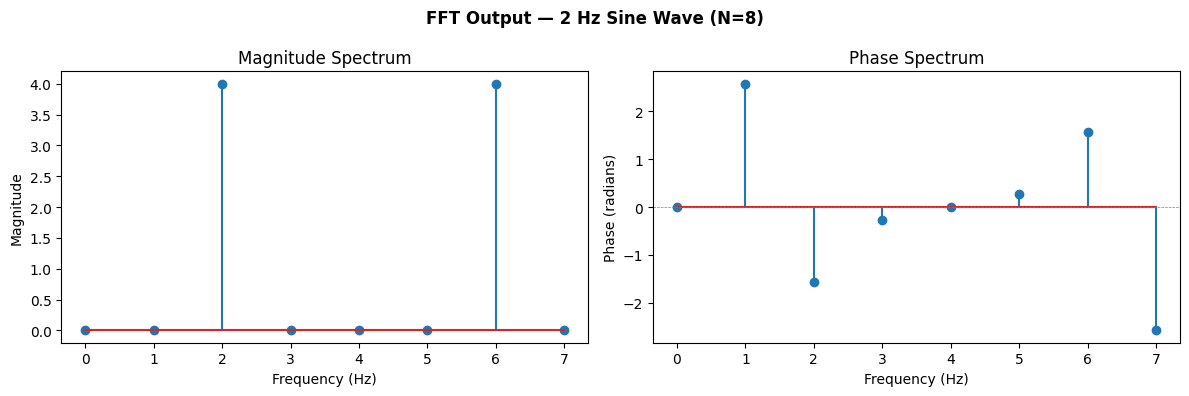

   k  Freq (Hz)    Magnitude  Phase (rad)
------------------------------------------
   0        0.0       0.0000       0.0000
   1        1.0       0.0000       2.5728
   2        2.0       4.0000      -1.5708
   3        3.0       0.0000      -0.2735
   4        4.0       0.0000       0.0000
   5        5.0       0.0000       0.2735
   6        6.0       4.0000       1.5708
   7        7.0       0.0000      -2.5728


In [6]:
# Visualization

# DFT/FFT output is complex (x = a + ib) — two meaningful things to plot:
#   Magnitude — how much of each frequency is present  |  abs(X[k])
#   Phase     — where in the cycle that frequency starts |  cmath.phase(X[k])


freqs  = [k * sample_rate / N for k in range(N)]  # bin index → Hz
mags   = [abs(val)           for val in output]    # magnitude spectrum
phases = [cmath.phase(val)   for val in output]    # phase spectrum (radians)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("FFT Output — 2 Hz Sine Wave (N=8)", fontweight='bold')

# --- Magnitude Spectrum ---
axes[0].stem(freqs, mags)
axes[0].set_title("Magnitude Spectrum")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude")
axes[0].set_xticks(freqs)

# --- Phase Spectrum ---
axes[1].stem(freqs, phases)
axes[1].set_title("Phase Spectrum")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Phase (radians)")
axes[1].set_xticks(freqs)
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

# --- Quick readout ---
print(f"{'k':>4} {'Freq (Hz)':>10} {'Magnitude':>12} {'Phase (rad)':>12}")
print("-" * 42)
for k, (f, m, p) in enumerate(zip(freqs, mags, phases)):
    print(f"{k:>4} {f:>10.1f} {m:>12.4f} {p:>12.4f}")


     N |    DFT (s) |    FFT (s) |    Speedup
--------------------------------------------
     4 |   0.000000 |   0.000000 |       infx
    16 |   0.000000 |   0.000000 |       infx
    64 |   0.000000 |   0.000000 |       infx
   256 |   0.000000 |   0.001177 |      0.00x
  1024 |   0.000000 |   0.005654 |      0.00x
  4096 |   0.000000 |   0.022696 |      0.00x


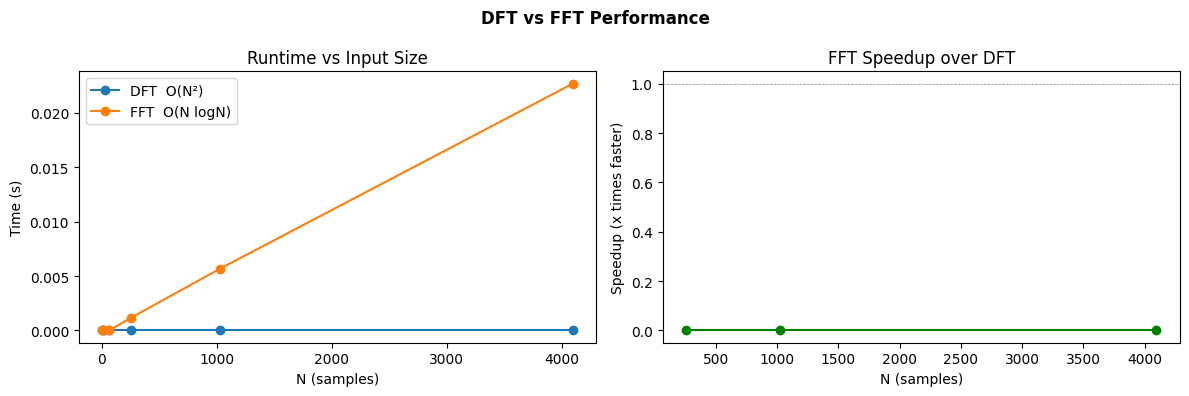

In [14]:
# Performance

# We know DFT is O(N²) and FFT is O(N logN) theoretically — but how does this play out
# on real data? Below we run both on increasing input sizes and measure the difference.
# Note: N must be a power of 2 for our FFT implementation

powers = [2, 4, 6, 8, 10, 12]

print(f"{'N':>6} | {'DFT (s)':>10} | {'FFT (s)':>10} | {'Speedup':>10}")
print("-" * 44)

results = []

for p in powers:
    N = 2**p
    # generate a simple sine wave at each size
    sample_rate = N
    t           = [n / sample_rate for n in range(N)]
    x           = [math.sin(2 * math.pi * 2 * ti) for ti in t]

    # --- DFT ---
    timer.set()
    t_dft = timer.stop()

    # --- FFT ---
    output = []
    w      = cmath.exp(-1j * 2 * cmath.pi / N)
    timer.set()
    fft(x, output, N, w)
    t_fft = timer.stop()

    # --- Results ---
    speedup = t_dft / t_fft if t_fft > 0 else float('inf')
    print(f"{N:>6} | {t_dft:>10.6f} | {t_fft:>10.6f} | {speedup:>9.2f}x")

    results.append((N, t_dft, t_fft, speedup))

# %timeit dft(x)
# %timeit np.fft.fft(x)

# --- Plot Results ---
Ns       = [r[0] for r in results]
t_dfts   = [r[1] for r in results]
t_ffts   = [r[2] for r in results]
speedups = [r[3] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("DFT vs FFT Performance", fontweight='bold')

# --- Runtime comparison ---
axes[0].plot(Ns, t_dfts, marker='o', label='DFT  O(N²)')
axes[0].plot(Ns, t_ffts, marker='o', label='FFT  O(N logN)')
axes[0].set_title("Runtime vs Input Size")
axes[0].set_xlabel("N (samples)")
axes[0].set_ylabel("Time (s)")
axes[0].legend()

# --- Speedup ---
axes[1].plot(Ns, speedups, marker='o', color='green')
axes[1].set_title("FFT Speedup over DFT")
axes[1].set_xlabel("N (samples)")
axes[1].set_ylabel("Speedup (x times faster)")
axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.5)  # baseline — no speedup

plt.tight_layout()
plt.show()


## Supporting Notes

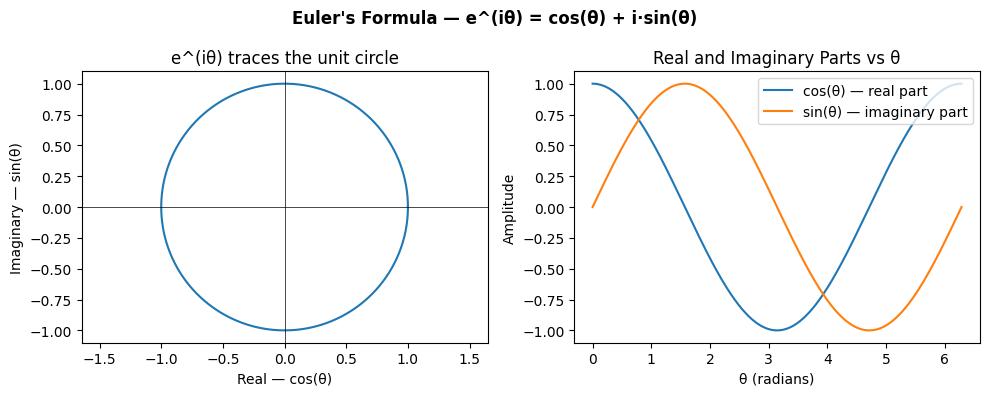

In [8]:
# Euler's Formula Visualization 

# Euler's formula states: e^(iθ) = cos(θ) + i·sin(θ)
# This means raising e to an imaginary power doesn't grow or decay — it rotates.
# As θ increases, e^(iθ) traces the unit circle in the complex plane.
# The real part tracks the x coordinate (cosine), the imaginary part tracks y (sine).
# This is the geometric foundation of why complex exponentials appear in the DFT —
# each e^(-i2πkn/N) term is a point rotating around the unit circle at frequency k.

theta = np.linspace(0, 2 * np.pi, 1000)  # θ from 0 to 2π — one full rotation
z     = np.exp(1j * theta)                # e^(iθ) — complex point on unit circle at each θ

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Euler's Formula — e^(iθ) = cos(θ) + i·sin(θ)", fontweight='bold')

# --- Left: unit circle in the complex plane ---
# every point on this circle is e^(iθ) for some θ
axes[0].plot(z.real, z.imag)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axvline(0, color='k', linewidth=0.5)
axes[0].axis('equal')
axes[0].set_title('e^(iθ) traces the unit circle')
axes[0].set_xlabel('Real — cos(θ)')
axes[0].set_ylabel('Imaginary — sin(θ)')

# --- Right: real and imaginary parts unpacked over θ ---
# shows that the complex exponential is just cosine and sine riding together
axes[1].plot(theta, z.real, label='cos(θ) — real part')
axes[1].plot(theta, z.imag, label='sin(θ) — imaginary part')
axes[1].set_title('Real and Imaginary Parts vs θ')
axes[1].set_xlabel('θ (radians)')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

plt.tight_layout()
plt.show()

## Inverse Discrete Fourier Transform

The inverse DFT reconstructs the original signal from its frequency domain representation —
the complete round trip back from frequency space to time/spatial domain. <br><br>

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \cdot e^{+i2\pi kn/N}$$

- **x[n]** — reconstructed time domain sample at position n
- **X[k]** — complex frequency bin k, output of the forward DFT
- **1/N** — normalization, balances the forward transform
- **e^{+i2πkn/N}** — complex exponential with flipped sign vs forward transform, undoes the rotation

In [9]:
# Inverse DFT (manual implementation)

# signal → DFT → IDFT → original signal

def idft(X):
    N  = len(X)
    x  = []
    for n in range(N):              # for each output time sample
        xn = complex(0, 0)
        for k in range(N):          # sum over all frequency bins
            angle  =  2 * cmath.pi * k * n / N   # note: positive angle
            xn    += X[k] * cmath.exp(1j * angle)
        x.append(xn / N)            # normalize by N
    return x

# verify round trip
sample_rate = 8
N           = 8
t           = [n / sample_rate for n in range(N)]
x           = [math.sin(2 * math.pi * 2 * ti) for ti in t]

X          = dft(x)
x_rebuilt  = idft(X)

for orig, rebuilt in zip(x, x_rebuilt):
    print(f"original: {orig:.4f}  rebuilt: {rebuilt.real:.4f}")


original: 0.0000  rebuilt: -0.0000
original: 1.0000  rebuilt: 1.0000
original: 0.0000  rebuilt: -0.0000
original: -1.0000  rebuilt: -1.0000
original: -0.0000  rebuilt: 0.0000
original: 1.0000  rebuilt: 1.0000
original: 0.0000  rebuilt: 0.0000
original: -1.0000  rebuilt: -1.0000
